## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : [Adult Income Prediction]

## Problem Statement

[Many organizations need to understand the factors that influence individuals' income levels. This project aims to predict whether a person earns more than $50K annually based on demographic and employment-related features.]

## Data Info
Data Source : https://www.kaggle.com/datasets/mosapabdelghany/adult-income-prediction-dataset

## Data Dictionary
| Column         | Type        | Description                  |
| -------------- | ----------- | ---------------------------- |
| age            | Numerical   | Age of individual            |
| workclass      | Categorical | Type of employment           |
| fnlwgt         | Numerical   | Census population weight     |
| education      | Categorical | Education level              |
| education.num  | Numerical   | Education level encoded      |
| marital.status | Categorical | Marital status               |
| occupation     | Categorical | Job type                     |
| relationship   | Categorical | Household relationship       |
| race           | Categorical | Race category                |
| sex            | Categorical | Gender                       |
| capital.gain   | Numerical   | Capital gains                |
| capital.loss   | Numerical   | Capital losses               |
| hours.per.week | Numerical   | Weekly working hours         |
| native.country | Categorical | Country of origin            |
| income         | Categorical | Income class (>50K or <=50K) |


In [1]:
# start you EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [5]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [6]:
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

In [7]:
df = df.replace('?', np.nan)
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [8]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])


df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [9]:
numerical_features = df.select_dtypes(include=['int64']).columns
numerical_features

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')

In [10]:
len(numerical_features)

6

In [11]:
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

C:\Users\a0355\AppData\Local\Temp\ipykernel_28788\266441915.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='str')

In [12]:
len(categorical_features)

9

The dataset contains:

- 6 numerical features:
  age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week

- 9 categorical features:
  workclass, education, marital.status, occupation,
  relationship, race, sex, native.country, income

The target variable (income) is categorical, making this a binary classification problem.

In [13]:
df['income_binary'] = df['income'].map({
    '<=50K':0,
    '>50K':1
})

df[['income','income_binary']].head()

,income,income_binary
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [14]:
corr = df.corr(numeric_only=True)
corr

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income_binary
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756,0.234037
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768,-0.009463
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123,0.335154
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409,0.223329
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256,0.150526
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000,0.229689
income_binary,0.234037,-0.009463,0.335154,0.223329,0.150526,0.229689,1.000000


In [15]:
corr['income_binary'].sort_values(ascending=False)

income_binary     1.000000
education.num     0.335154
age               0.234037
hours.per.week    0.229689
capital.gain      0.223329
capital.loss      0.150526
fnlwgt           -0.009463
Name: income_binary, dtype: float64

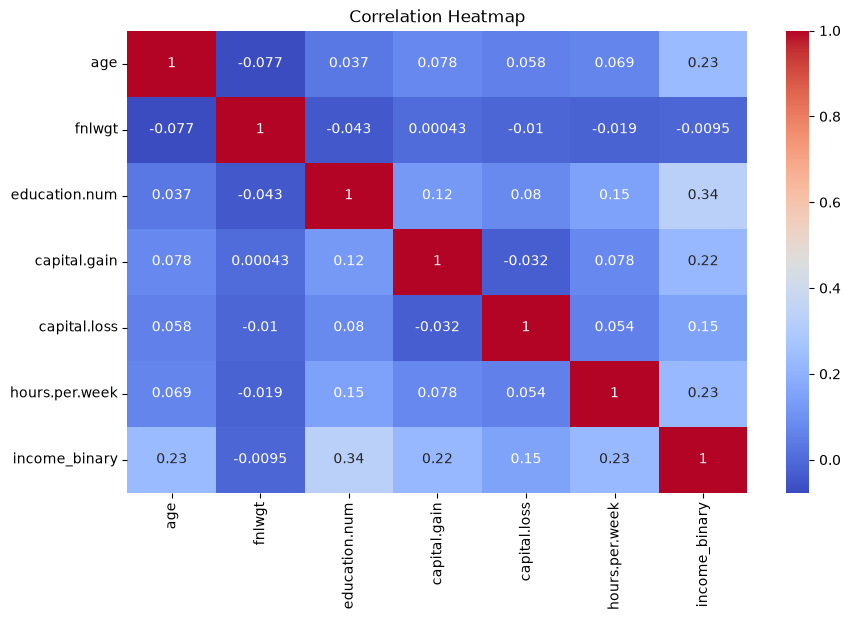

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Education level has the strongest positive correlation with income, suggesting that higher education levels are associated with higher income.\

Age shows a positive relationship with income, indicating that older individuals tend to have higher income levels.

Weekly working hours have a positive correlation with income, suggesting that working more hours may increase earning potential.

#Correlation Analysis
The correlation analysis shows that education.num has the strongest positive correlation with income (0.34).
Other features with positive relationships include:
- age (0.23)
- hours.per.week (0.23)
- capital.gain (0.22)
This suggests that education level, age, working hours, and capital gains may play an important role in predicting income.
The fnlwgt feature shows almost no correlation with income (-0.009), indicating a weak relationship.

#Outliers Analysis

Boxplot analysis shows the presence of outliers mainly in:
- fnlwgt
- capital.gain
- capital.loss

These values were investigated and considered valid because they represent real variations in the population data rather than data entry errors.

Instead of removing these observations, outliers will be handled during the modeling stage using appropriate preprocessing techniques if needed.

The dataset contained missing values represented as "?". These values were converted into NaN. Missing values were found in workclass, occupation, and native.country. Since these features are categorical, missing values were replaced using the mode (most frequent value).

In [18]:
# ## Feature Types Analysis

# The dataset contains a combination of numerical and categorical features.

# ### Numerical Features (6):
# - product_rating
# - total_reviews
# - purchased_last_month
# - discounted_price
# - original_price
# - discount_percentage


# ### Categorical Features (5):
# - is_best_seller
# - is_sponsored
# - has_coupon
# - buy_box_availability
# - product_category


# The target variable is **purchased_last_month**, which is a numerical continuous variable. Therefore, this project is considered a regression problem.

# Topic 2 : [Amazon Products Sales Dataset 42K+ Items - 2025]

## Problem Statement

[E-commerce platforms need to understand which product characteristics influence customer purchases. This project aims to predict the number of products purchased in the last month based on pricing, ratings, discounts, and product attributes.]

## Data Info
Data Source : https://www.kaggle.com/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025?select=amazon_products_sales_data_uncleaned.csv

## Data Dictionary
| Column                   | Type  |
| ------------------------ | ----------- |
| title                    | object      |
| rating                   | object      |
| number_of_reviews        | object      |
| bought_in_last_month     | object      |
| current/discounted_price | object      |
| price_on_variant         | object      |
| listed_price             | object      |
| is_best_seller           | object      |
| is_sponsored             | object      |
| is_couponed              | object      |
| buy_box_availability     | object      |
| delivery_details         | object      |
| sustainability_badges    | object      |
| image_url                | object      |
| product_url              | object      |
| collected_at             | object      |


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df2 = pd.read_csv('amazon_products_sales_data_cleaned.csv')
df2.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [21]:
df2.shape

(42675, 17)

In [22]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  str    
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  str    
 7   is_sponsored          42675 non-null  str    
 8   has_coupon            42675 non-null  str    
 9   buy_box_availability  28022 non-null  str    
 10  delivery_date         30692 non-null  str    
 11  sustainability_tags   3408 non-null   str    
 12  product_image_url     42675 non-null  str    
 13  product_page_url      40606 non-null  str    
 14  data_collected_at     42675 non-null  str    
 15  product_category      42675 no

In [23]:
df2.isnull().sum()

product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

In [26]:
df2['purchased_last_month'].describe()

count     32164.000000
mean       1293.665278
std        6318.323574
min          50.000000
25%         100.000000
50%         200.000000
75%         400.000000
max      100000.000000
Name: purchased_last_month, dtype: float64

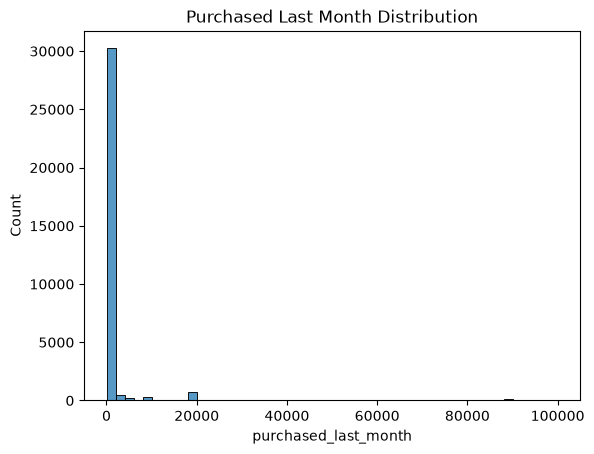

In [27]:
sns.histplot(
    data=df2,
    x='purchased_last_month',
    bins=50
)

plt.title("Purchased Last Month Distribution")
plt.show()

Target Variable Analysis

The target variable is **purchased_last_month**, which represents the number of units purchased for each product during the previous month.

Since the target variable is numerical and continuous, this is a regression problem.

The distribution shows a strong right skew, where most products have relatively low purchase numbers while a small number of products have extremely high sales values.

The mean value (1293) is much higher than the median (200), indicating the presence of highly successful products that create outliers.

In [28]:
df2.shape

(42675, 17)

In [29]:
df2 = df2.dropna(subset=['purchased_last_month'])

df2.shape

(32164, 17)

In [30]:
df2.isnull().sum()

product_title               0
product_rating             76
total_reviews              76
purchased_last_month        0
discounted_price         1860
original_price           1860
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability     8662
delivery_date            7099
sustainability_tags     29422
product_image_url           0
product_page_url         2066
data_collected_at           0
product_category            0
discount_percentage      1860
dtype: int64

In [31]:
df2.dtypes

product_title               str
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller              str
is_sponsored                str
has_coupon                  str
buy_box_availability        str
delivery_date               str
sustainability_tags         str
product_image_url           str
product_page_url            str
data_collected_at           str
product_category            str
discount_percentage     float64
dtype: object

In [33]:
df2 = df2.drop(columns=[
    'product_title',
    'product_image_url',
    'product_page_url',
    'data_collected_at',
    'sustainability_tags'
])

In [34]:
df2.shape

(32164, 12)

In [35]:
df2.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'is_best_seller', 'is_sponsored',
       'has_coupon', 'buy_box_availability', 'delivery_date',
       'product_category', 'discount_percentage'],
      dtype='str')

In [36]:
df2.isnull().sum()

product_rating            76
total_reviews             76
purchased_last_month       0
discounted_price        1860
original_price          1860
is_best_seller             0
is_sponsored               0
has_coupon                 0
buy_box_availability    8662
delivery_date           7099
product_category           0
discount_percentage     1860
dtype: int64

In [37]:
df2['product_rating'] = df2['product_rating'].fillna(df2['product_rating'].median())

df2['total_reviews'] = df2['total_reviews'].fillna(df2['total_reviews'].median())

df2['discounted_price'] = df2['discounted_price'].fillna(df2['discounted_price'].median())

df2['original_price'] = df2['original_price'].fillna(df2['original_price'].median())

df2['discount_percentage'] = df2['discount_percentage'].fillna(df2['discount_percentage'].median())

In [38]:
df2.isnull().sum()

product_rating             0
total_reviews              0
purchased_last_month       0
discounted_price           0
original_price             0
is_best_seller             0
is_sponsored               0
has_coupon                 0
buy_box_availability    8662
delivery_date           7099
product_category           0
discount_percentage        0
dtype: int64

In [39]:
df2['buy_box_availability'] = df2['buy_box_availability'].fillna('No')

df2 = df2.drop(columns=['delivery_date'])

In [40]:
df2.isnull().sum()

product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
is_best_seller          0
is_sponsored            0
has_coupon              0
buy_box_availability    0
product_category        0
discount_percentage     0
dtype: int64

In [41]:
numerical_features = df2.select_dtypes(include=['int64','float64']).columns

categorical_features = df2.select_dtypes(include=['object']).columns


print("Numerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))


print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Numerical Features:
Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage'],
      dtype='str')

Number of Numerical Features: 6

Categorical Features:
Index(['is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability',
       'product_category'],
      dtype='str')

Number of Categorical Features: 5


C:\Users\a0355\AppData\Local\Temp\ipykernel_28788\245030686.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df2.select_dtypes(include=['object']).columns


Feature Types Analysis

The dataset contains a combination of numerical and categorical features.

Numerical Features (6):
- product_rating
- total_reviews
- purchased_last_month
- discounted_price
- original_price
- discount_percentage


Categorical Features (5):
- is_best_seller
- is_sponsored
- has_coupon
- buy_box_availability
- product_category


The target variable is **purchased_last_month**, which is a numerical continuous variable. Therefore, this project is considered a regression problem.

In [42]:
corr = df2.corr(numeric_only=True)

corr['purchased_last_month'].sort_values(ascending=False)

purchased_last_month    1.000000
total_reviews           0.296020
product_rating          0.151771
discount_percentage     0.047579
original_price         -0.085461
discounted_price       -0.091971
Name: purchased_last_month, dtype: float64

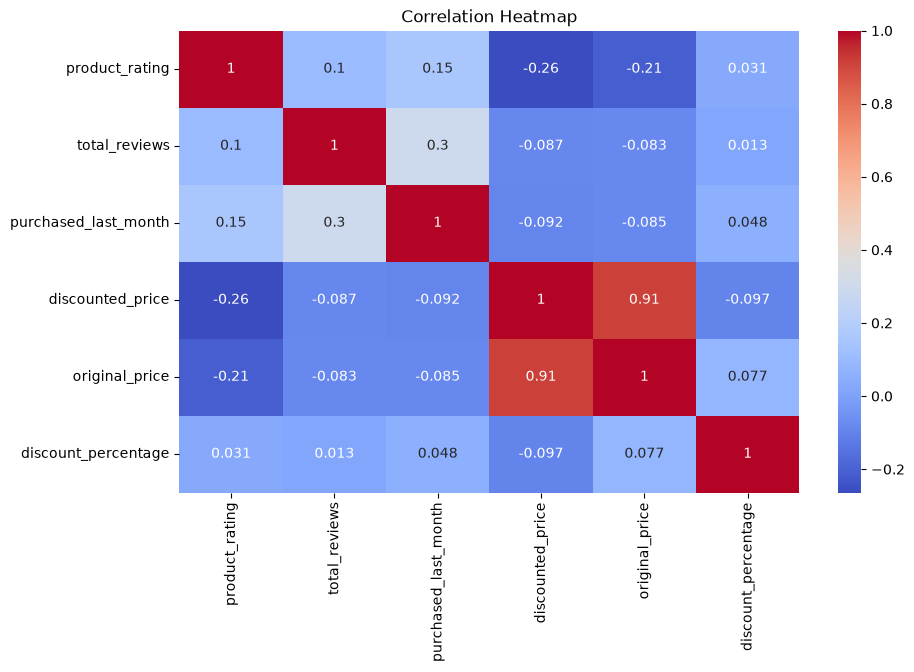

In [43]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

<!-- ## Correlation Analysis -->

The correlation analysis shows that **total_reviews** has the strongest positive relationship with the target variable (purchased_last_month) with a correlation value of approximately 0.30. This indicates that products with more customer reviews tend to have higher purchase numbers.

Product rating also shows a positive but weaker relationship with sales.

Price-related features (original_price and discounted_price) have weak negative correlations with purchases, suggesting that higher-priced products do not necessarily achieve higher sales.

A strong correlation was observed between original_price and discounted_price (0.91), indicating that these variables provide similar information and may require further consideration during modeling.

In [ ]:
# # # EDA Summary

# The target variable is **purchased_last_month**, which represents the number of units purchased for each product during the previous month. Since the target variable is numerical and continuous, this is a **regression problem**. The target distribution is highly right-skewed, where most products have relatively low purchase values, while a small number of products have extremely high sales values. Therefore, the target is not considered balanced (balance is mainly applied to classification problems).

# The dataset contains **6 numerical features**: product_rating, total_reviews, purchased_last_month, discounted_price, original_price, and discount_percentage. It also contains **5 categorical features**: is_best_seller, is_sponsored, has_coupon, buy_box_availability, and product_category.

# Missing values were found in several features. Numerical missing values in product_rating, total_reviews, discounted_price, original_price, and discount_percentage were handled using the median because it is less affected by outliers. Missing values in buy_box_availability were replaced with "No" because NaN values represent unavailable Buy Box. Columns with a high percentage of missing values or irrelevant information were removed.

# Correlation analysis showed that **total_reviews** had the strongest positive relationship with the target (correlation ≈ 0.30), indicating that products with more reviews tend to have higher purchases. Product_rating also showed a positive but weaker relationship. A strong correlation was found between original_price and discounted_price (≈ 0.91), meaning they provide similar information.

# Outlier analysis showed extreme values mainly in total_reviews and purchased_last_month. These values represent highly popular products and best sellers rather than data errors, so they were not removed. Instead, they can be handled using techniques such as log transformation or robust models during the modeling stage.

In [24]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

# Topic 3 : [Credit Risk Modeling: Predicting Loan Approval Decisions]

## Problem Statement

[Financial institutions need accurate and efficient methods to evaluate loan applications while minimizing credit risk and ensuring responsible lending decisions. Manual assessment of applicants can be time-consuming and may lead to inconsistent decisions.

This project aims to develop a machine learning model that predicts whether a loan application will be approved or rejected based on applicants' financial information, credit history, employment details, and loan characteristics. The model can help financial institutions improve decision-making, reduce risk, and automate parts of the loan approval process.]

## Data Info
Data Source : https://www.kaggle.com/datasets/parthpatel2130/realistic-loan-approval-dataset-us-and-canada

## Data Dictionary
| Column                  | Type   | Description                                                                      |
| ----------------------- | ------ | -------------------------------------------------------------------------------- |
| customer_id             | object | Unique identifier for each loan applicant                                        |
| age                     | int    | Age of the applicant                                                             |
| occupation_status       | object | Employment status of the applicant                                               |
| years_employed          | float  | Number of years the applicant has been employed                                  |
| annual_income           | int    | Applicant's yearly income                                                        |
| credit_score            | int    | Credit score representing the applicant's creditworthiness                       |
| credit_history_years    | float  | Number of years of the applicant's credit history                                |
| savings_assets          | int    | Applicant's savings and available assets                                         |
| current_debt            | int    | Existing debt amount of the applicant                                            |
| defaults_on_file        | int    | Indicates whether the applicant has previous defaults                            |
| delinquencies_last_2yrs | int    | Number of payment delinquencies in the last 2 years                              |
| derogatory_marks        | int    | Number of negative credit marks                                                  |
| product_type            | object | Type of financial product requested (Credit Card, Personal Loan, Line of Credit) |
| loan_intent             | object | Purpose of the loan application                                                  |
| loan_amount             | int    | Requested loan amount                                                            |
| interest_rate           | float  | Interest rate applied to the loan                                                |
| debt_to_income_ratio    | float  | Ratio of applicant's debt compared to income                                     |
| loan_to_income_ratio    | float  | Ratio between requested loan amount and income                                   |
| payment_to_income_ratio | float  | Ratio of loan payment compared to income                                         |
| loan_status             | int    | Target variable: 1 = Approved, 0 = Rejected                                      |


In [45]:
df3 = pd.read_csv('Loan_approval_data_2025.csv')
df3.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [46]:
df3.shape

(50000, 20)

In [47]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  str    
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  str    
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  str    
 13  loan_intent              50000 non-null  str    
 14  loan_amount              50000 no

In [48]:
df3.isnull().sum()

customer_id                0
age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
product_type               0
loan_intent                0
loan_amount                0
interest_rate              0
debt_to_income_ratio       0
loan_to_income_ratio       0
payment_to_income_ratio    0
loan_status                0
dtype: int64

In [49]:
df3.columns

Index(['customer_id', 'age', 'occupation_status', 'years_employed',
       'annual_income', 'credit_score', 'credit_history_years',
       'savings_assets', 'current_debt', 'defaults_on_file',
       'delinquencies_last_2yrs', 'derogatory_marks', 'product_type',
       'loan_intent', 'loan_amount', 'interest_rate', 'debt_to_income_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status'],
      dtype='str')

Feature Types Analysis

The dataset contains two types of features:

Numerical Features (15):
- age
- years_employed
- annual_income
- credit_score
- credit_history_years
- savings_assets
- current_debt
- defaults_on_file
- delinquencies_last_2yrs
- derogatory_marks
- loan_amount
- interest_rate
- debt_to_income_ratio
- loan_to_income_ratio
- payment_to_income_ratio

Categorical Features (3):
- occupation_status
- product_type
- loan_intent

The column customer_id was considered an identifier and will not be used as a predictive feature.

In [50]:
df3['loan_status'].value_counts()

loan_status
1    27523
0    22477
Name: count, dtype: int64

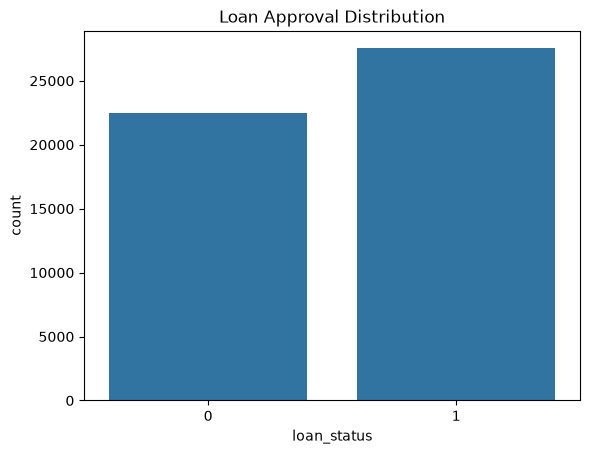

In [51]:
sns.countplot(
    data=df3,
    x='loan_status'
)

plt.title("Loan Approval Distribution")
plt.show()

In [52]:
corr = df3.corr(numeric_only=True)

corr['loan_status'].sort_values(ascending=False)

loan_status                1.000000
credit_score               0.496316
age                        0.311524
credit_history_years       0.277103
years_employed             0.218875
annual_income              0.158466
savings_assets             0.094789
loan_amount               -0.025987
current_debt              -0.088494
interest_rate             -0.185179
loan_to_income_ratio      -0.193252
payment_to_income_ratio   -0.193258
derogatory_marks          -0.224735
defaults_on_file          -0.263033
debt_to_income_ratio      -0.317363
delinquencies_last_2yrs   -0.318075
Name: loan_status, dtype: float64

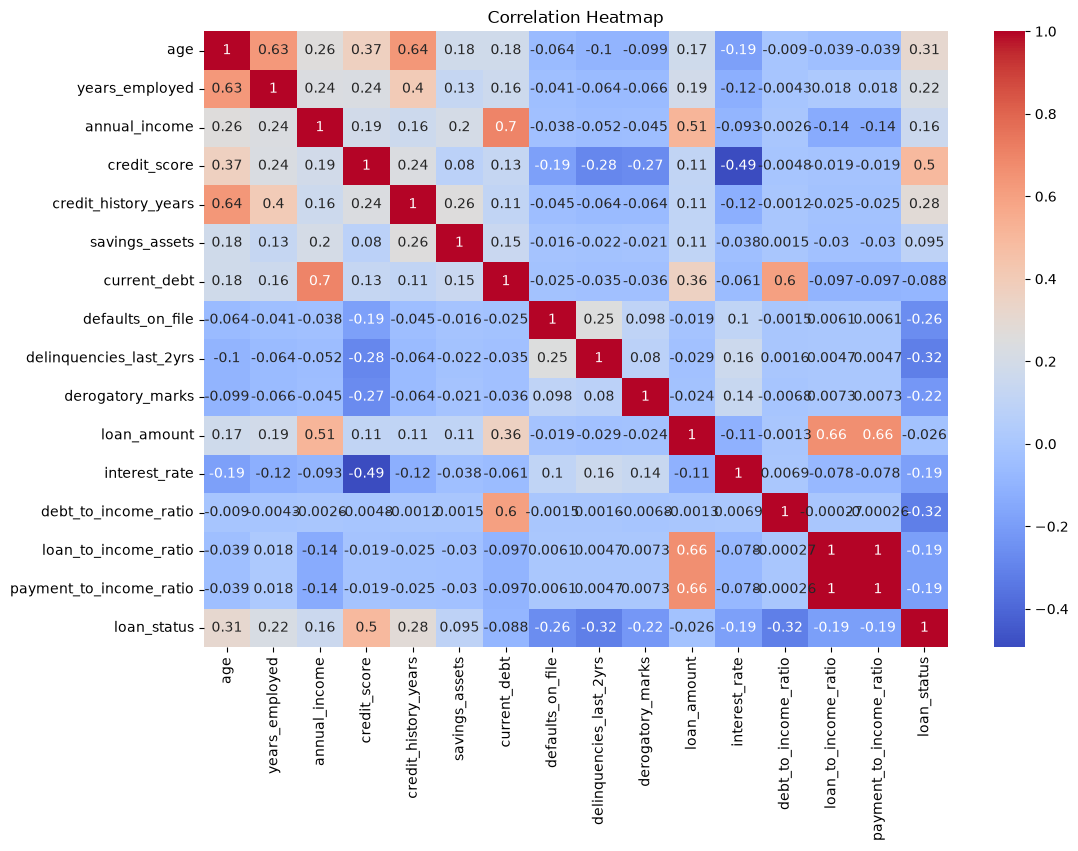

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ## EDA Summary

# The target variable is **loan_status**, which represents the final decision of the loan application:
# - 1: Approved
# - 0: Rejected

# Since the target contains two classes, this is a **binary classification problem**. The target distribution is relatively balanced, with 27,523 approved applications (55%) and 22,477 rejected applications (45%). Therefore, no class balancing techniques are required.

# The dataset contains two types of features:

# **Numerical Features (15):**
# - age
# - years_employed
# - annual_income
# - credit_score
# - credit_history_years
# - savings_assets
# - current_debt
# - defaults_on_file
# - delinquencies_last_2yrs
# - derogatory_marks
# - loan_amount
# - interest_rate
# - debt_to_income_ratio
# - loan_to_income_ratio
# - payment_to_income_ratio

# **Categorical Features (3):**
# - occupation_status
# - product_type
# - loan_intent

# The column **customer_id** was considered an identifier and will not be used as a predictive feature.

# The dataset contains **no missing values**, so no missing value treatment was required.

# Correlation analysis showed that **credit_score** had the strongest positive relationship with loan approval (correlation ≈ 0.50), indicating that applicants with higher credit scores are more likely to be approved. Other important positive features included age, credit_history_years, years_employed, and annual_income.

# Negative correlations were observed with risk-related features. Higher **debt_to_income_ratio**, **delinquencies_last_2yrs**, and **defaults_on_file** reduce the probability of loan approval because they indicate higher financial risk.

# A strong correlation was found between **loan_to_income_ratio** and **payment_to_income_ratio** (≈ 1.0), meaning these features provide very similar information and may cause multicollinearity during modeling.

# Outlier analysis showed outliers mainly in financial features such as **annual_income, savings_assets, current_debt, and loan_amount**. These values represent realistic cases of customers with high income, large assets, or large loan requests rather than data errors. Therefore, they will not be removed. Instead, they can be handled using techniques such as log transformation or robust machine learning models during the modeling stage.

In [ ]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?